In [1]:
!pip install lime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import lime.lime_tabular

In [2]:
df = pd.read_csv("/content/heart_statlog_cleveland_hungary_final (1).csv")
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [3]:
df.dropna(inplace=True)
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [4]:
df.duplicated().sum()

np.int64(272)

In [5]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# View them
print(duplicate_rows)

Number of duplicate rows: 272
      age  sex  chest pain type  resting bp s  cholesterol  \
163    49    0                2           110          208   
604    58    1                3           150          219   
887    63    1                1           145          233   
888    67    1                4           160          286   
889    67    1                4           120          229   
...   ...  ...              ...           ...          ...   
1156   42    1                3           130          180   
1157   61    1                4           140          207   
1158   66    1                4           160          228   
1159   46    1                4           140          311   
1160   71    0                4           112          149   

      fasting blood sugar  resting ecg  max heart rate  exercise angina  \
163                     0            0             160                0   
604                     0            1             118                1   


In [6]:
df.drop_duplicates(inplace=True)
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


Class distribution (counts):
 target
1    508
0    410
Name: count, dtype: int64

Class distribution (percentages):
 target
1    55.34
0    44.66
Name: proportion, dtype: float64


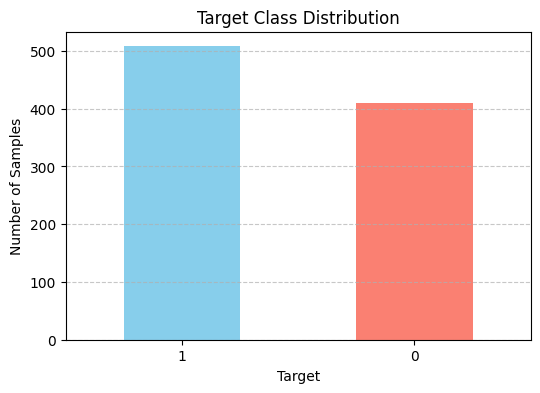

In [7]:
# Assuming df_cleaned is your cleaned DataFrame
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True) * 100

# Print numerical summary
print("Class distribution (counts):\n", class_counts)
print("\nClass distribution (percentages):\n", class_percentages.round(2))

# Plot
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Class Distribution')
plt.xlabel('Target')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
X = df.drop('target', axis=1)
y = df['target']
adasyn = ADASYN(random_state=42, sampling_strategy='minority')
X_resampled, y_resampled = adasyn.fit_resample(X, y)

In [9]:
# Combine X and y into a new DataFrame
df_adasyn = pd.DataFrame(X_resampled, columns=X.columns)
df_adasyn['target'] = y_resampled

# Optional: Shuffle the data
df_adasyn = df_adasyn.sample(frac=1, random_state=42).reset_index(drop=True)

# Preview
print(df_adasyn.head())
print(df_adasyn['target'].value_counts())

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   74    1                3           140          237                    1   
1   73    1                3           138            0                    0   
2   43    1                4           150          247                    0   
3   65    1                4           170          263                    1   
4   48    0                4           150          227                    0   

   resting ecg  max heart rate  exercise angina   oldpeak  ST slope  target  
0            0              94                0  0.000000         2       1  
1            0             116                0  0.196807         1       0  
2            0             130                1  2.000000         2       1  
3            0             112                1  2.000000         2       1  
4            0             130                1  1.000000         2       0  
target
1    508
0    439
Name: count, dtype: int64


In [10]:
df = df_adasyn

# **EDA**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  947 non-null    int64  
 1   sex                  947 non-null    int64  
 2   chest pain type      947 non-null    int64  
 3   resting bp s         947 non-null    int64  
 4   cholesterol          947 non-null    int64  
 5   fasting blood sugar  947 non-null    int64  
 6   resting ecg          947 non-null    int64  
 7   max heart rate       947 non-null    int64  
 8   exercise angina      947 non-null    int64  
 9   oldpeak              947 non-null    float64
 10  ST slope             947 non-null    int64  
 11  target               947 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 88.9 KB


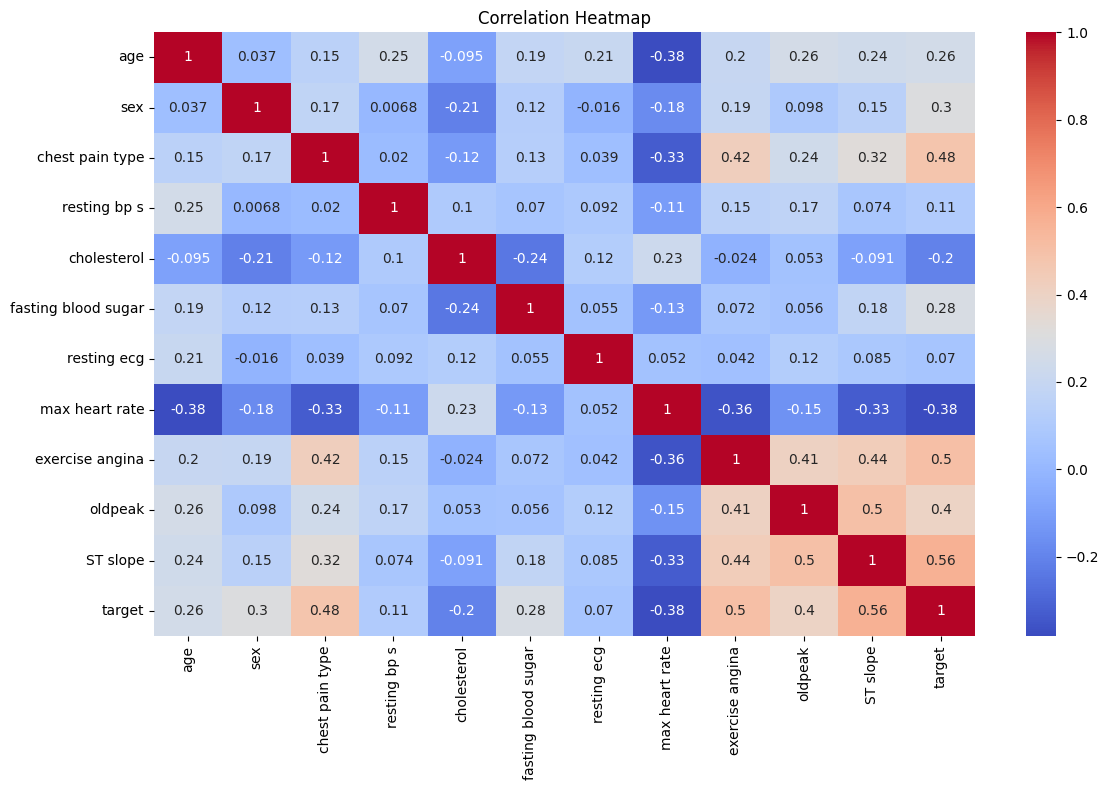

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [13]:
df['bp_cp_interaction'] = df['resting bp s'] * df['chest pain type']
df['angina_cp_interaction'] = df['exercise angina'] * df['chest pain type']
df['angina_hr_product'] = df['exercise angina'] * df['max heart rate']

In [14]:
df.drop(columns=['max heart rate', 'resting ecg', 'cholesterol', 'resting bp s'], inplace=True)

In [15]:
df.rename(columns={
    'chest pain type': 'cp',
    'resting bp s': 'trestbps',
    'cholesterol': 'chol',
    'fasting blood sugar': 'fbs',
    'resting ecg': 'restecg',
    'max heart rate': 'thalach',
    'exercise angina': 'exang',
    'ST slope': 'slope'
}, inplace=True)


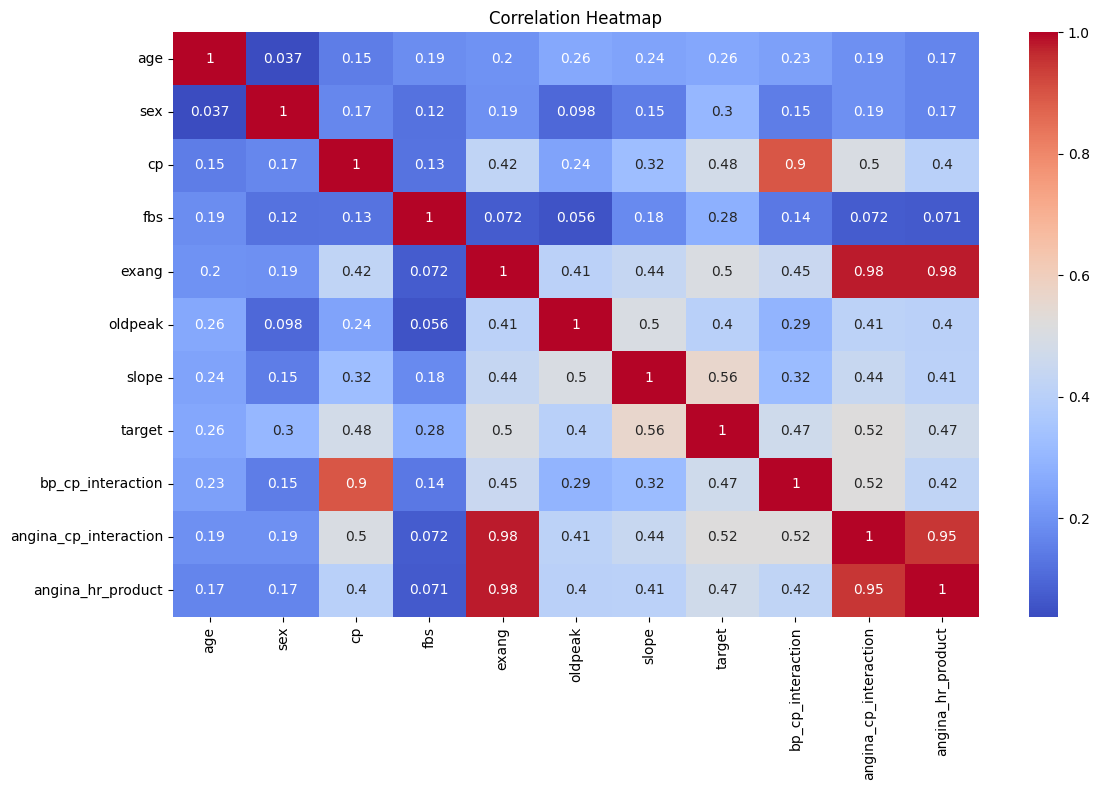

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    947 non-null    int64  
 1   sex                    947 non-null    int64  
 2   cp                     947 non-null    int64  
 3   fbs                    947 non-null    int64  
 4   exang                  947 non-null    int64  
 5   oldpeak                947 non-null    float64
 6   slope                  947 non-null    int64  
 7   target                 947 non-null    int64  
 8   bp_cp_interaction      947 non-null    int64  
 9   angina_cp_interaction  947 non-null    int64  
 10  angina_hr_product      947 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 81.5 KB


<ipython-input-18-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


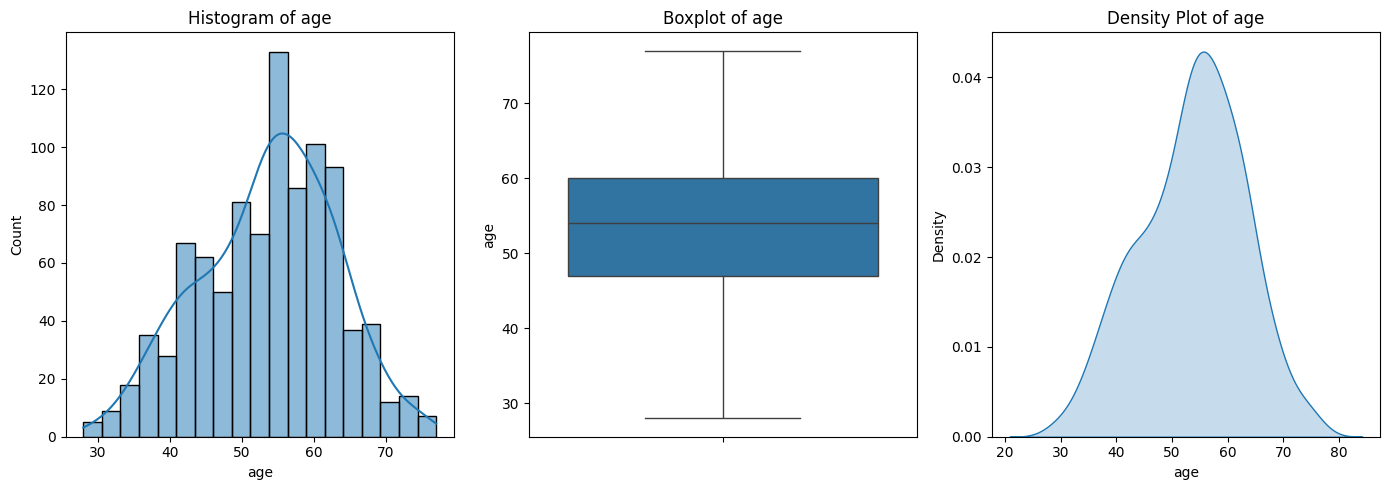

<ipython-input-18-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


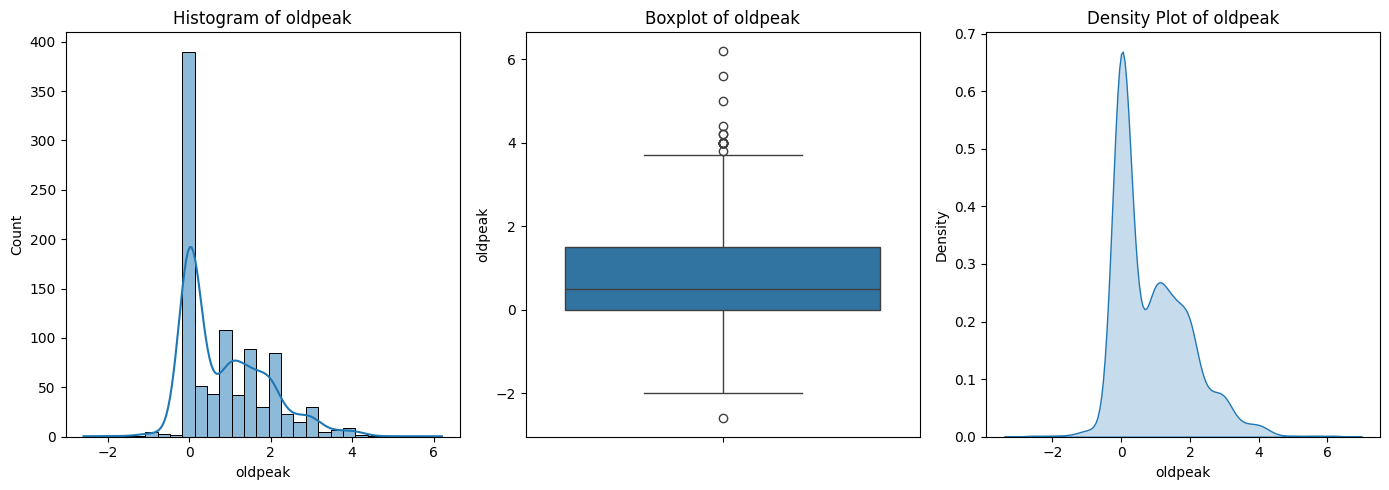

<ipython-input-18-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


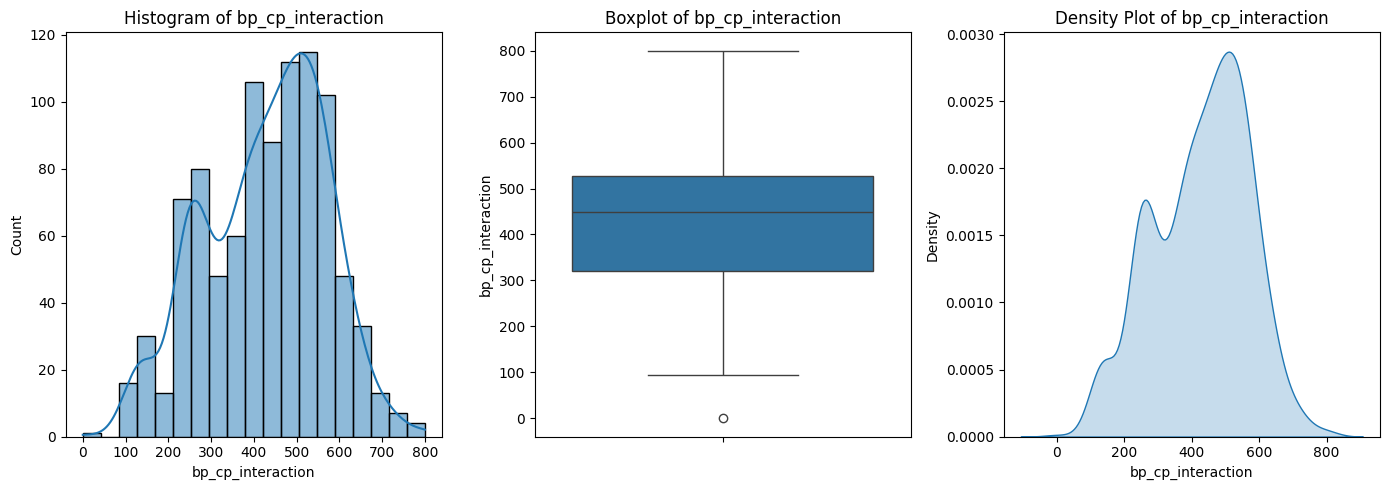

<ipython-input-18-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


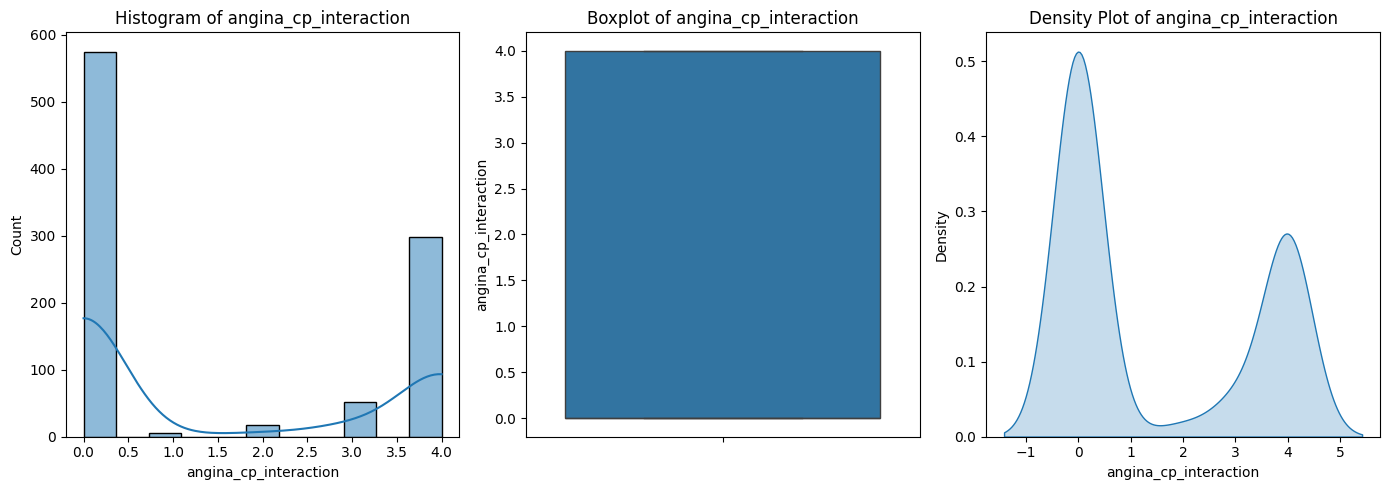

<ipython-input-18-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


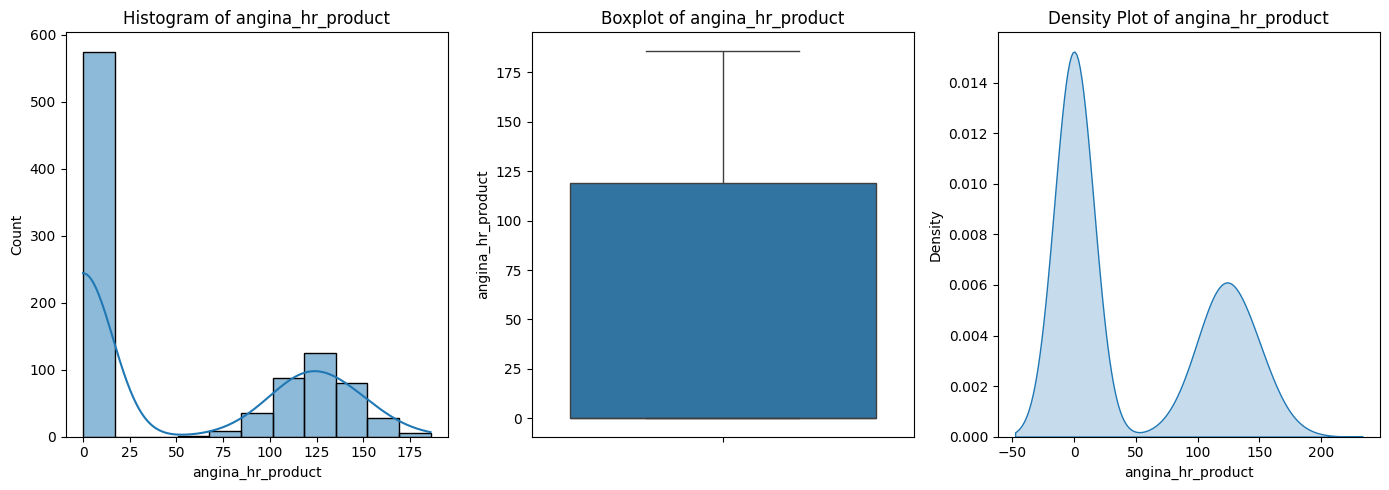

In [18]:
numeric_cols = ['age', 'oldpeak', 'bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product']

# Histograms and Boxplots for Numerical Features
for col in numeric_cols:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], shade=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()

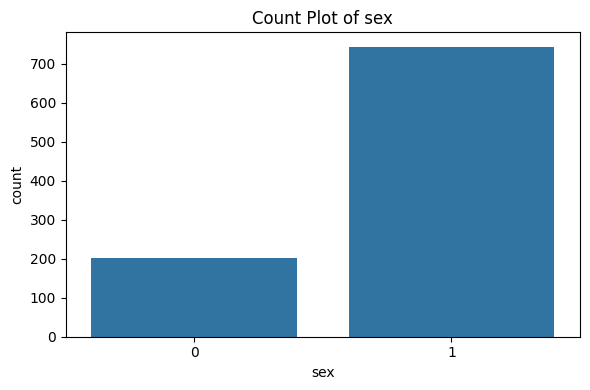

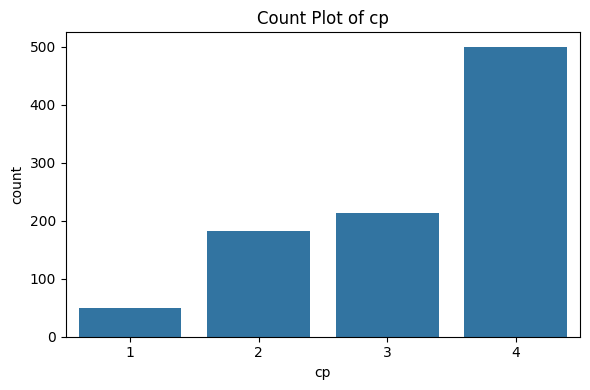

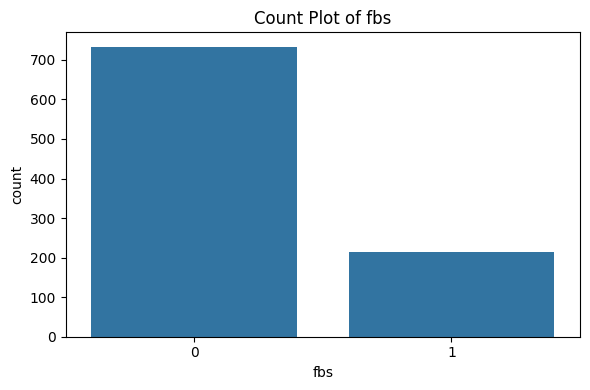

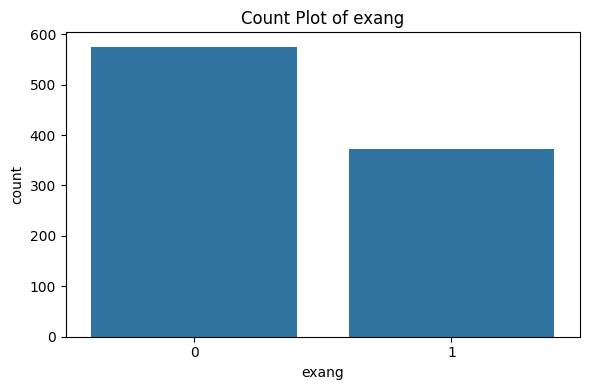

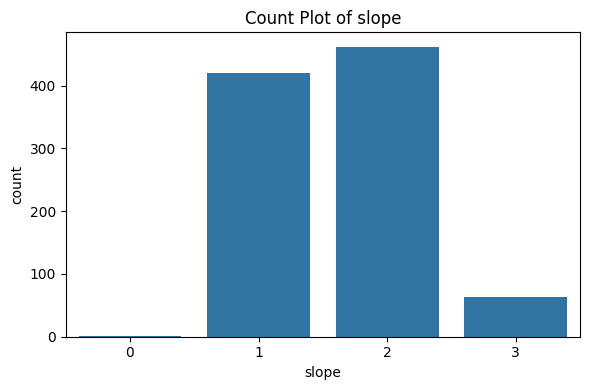

In [19]:
categorical_cols = ['sex', 'cp', 'fbs', 'exang', 'slope']

# Categorical Features
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.tight_layout()
    plt.show()

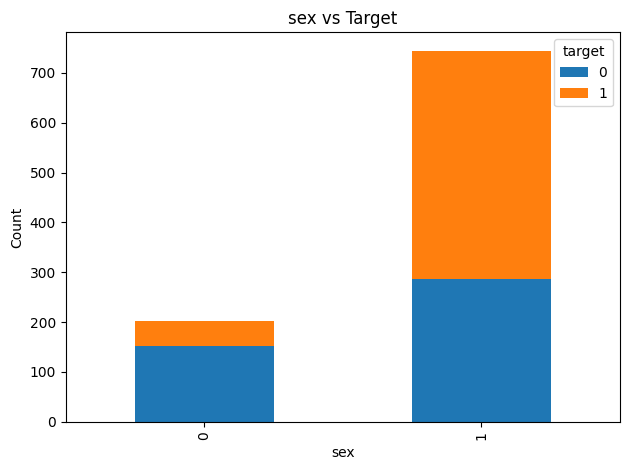

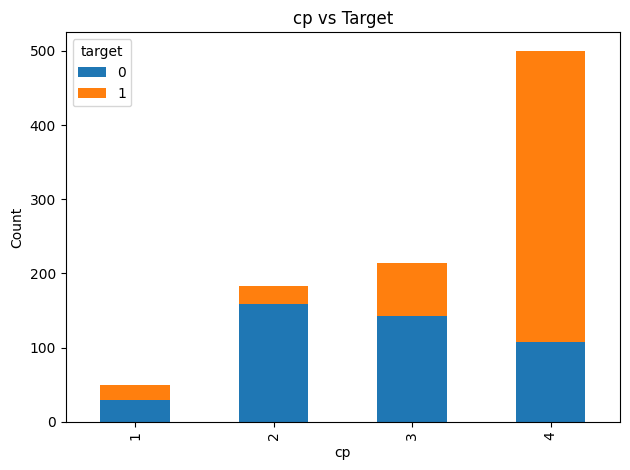

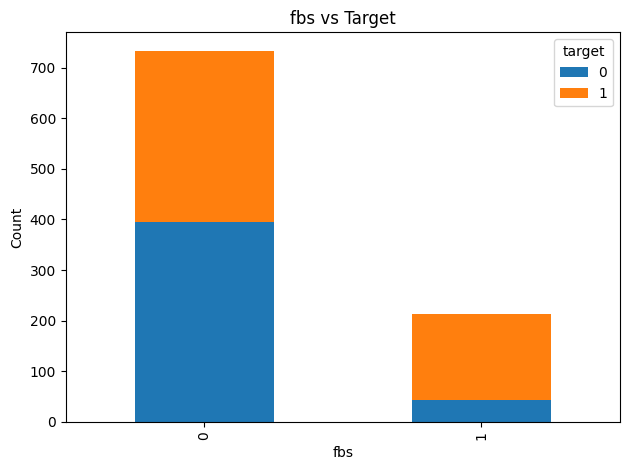

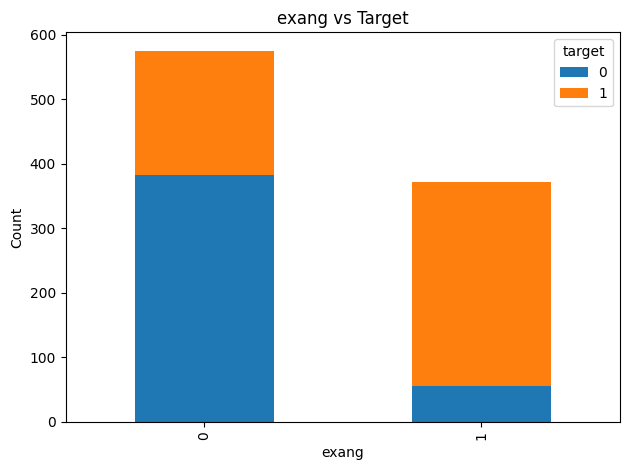

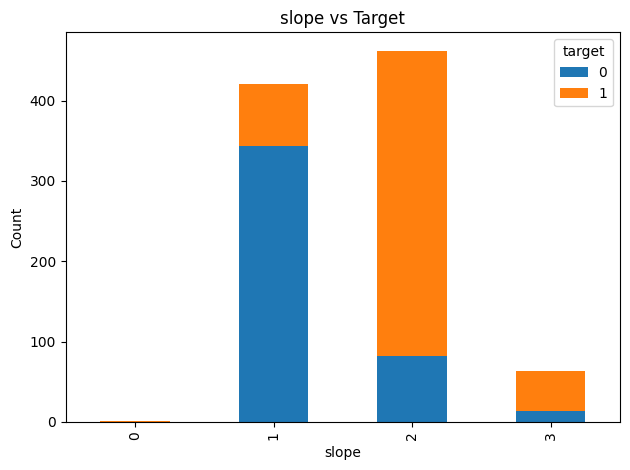

In [20]:
#Categorical vs Target
for col in categorical_cols:
    pd.crosstab(df[col], df['target']).plot(kind='bar', stacked=True)
    plt.title(f'{col} vs Target')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

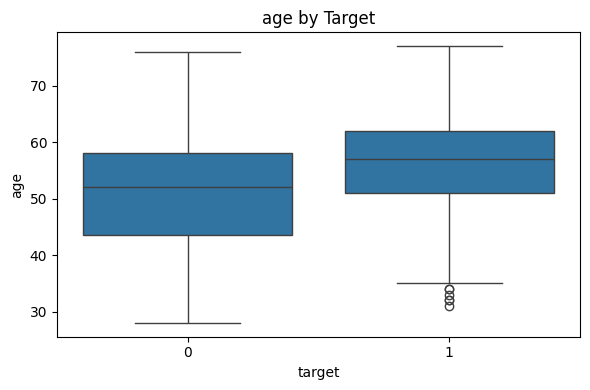

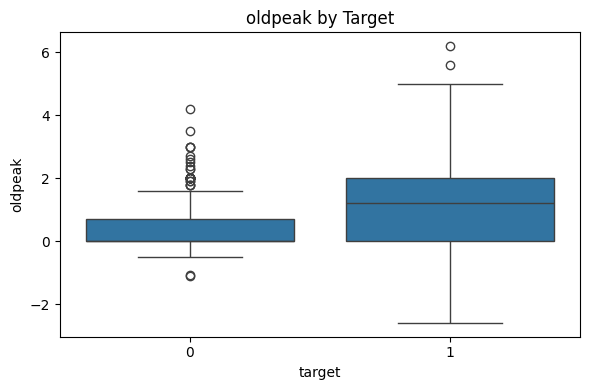

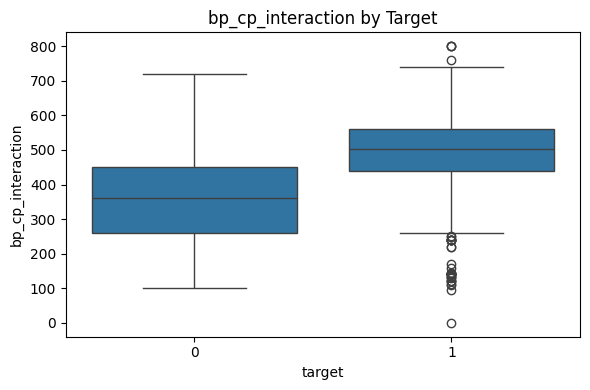

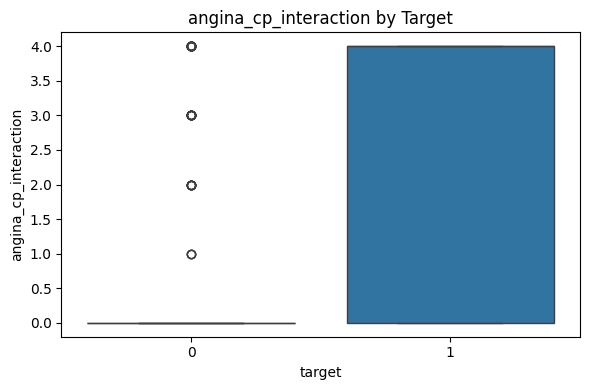

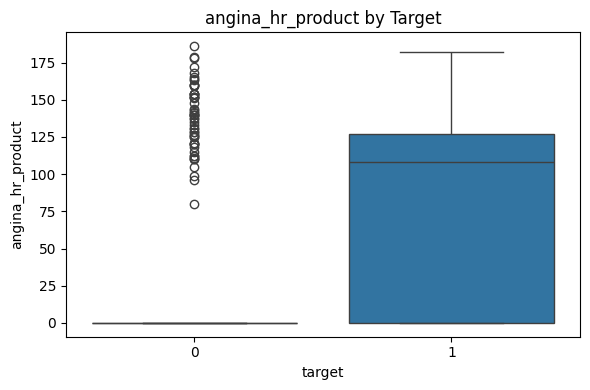

In [21]:
# Numerical vs Target
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} by Target')
    plt.tight_layout()
    plt.show()

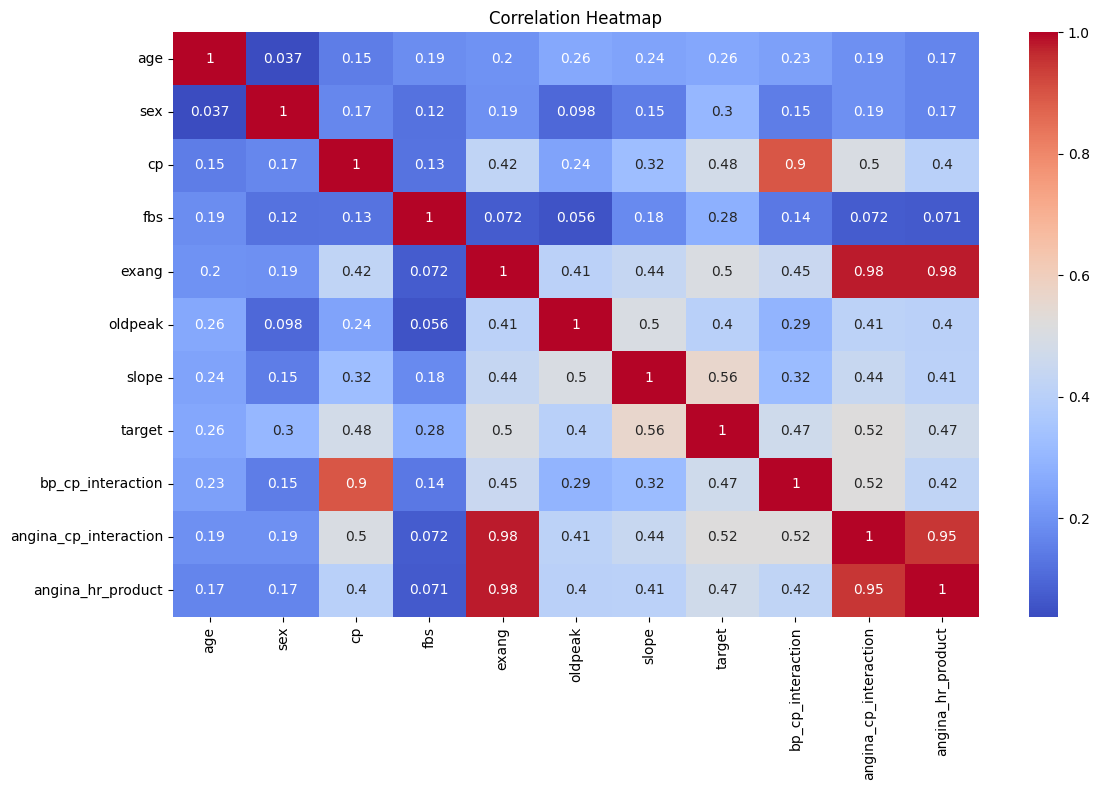

In [22]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [23]:
def replace_outliers_with_median(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    median = column.median()
    return column.apply(lambda x: median if x < lower or x > upper else x)


for col in numeric_cols:
    df[col] = replace_outliers_with_median(df[col])

print(df[numeric_cols].describe())

              age    oldpeak  bp_cp_interaction  angina_cp_interaction  \
count  947.000000  947.00000         947.000000             947.000000   
mean    53.662091    0.82167         428.269271               1.462513   
std      9.443381    0.95679         140.265854               1.860749   
min     28.000000   -2.00000          95.000000               0.000000   
25%     47.000000    0.00000         320.000000               0.000000   
50%     54.000000    0.50000         448.000000               0.000000   
75%     60.000000    1.50000         528.000000               4.000000   
max     77.000000    3.70000         800.000000               4.000000   

       angina_hr_product  
count         947.000000  
mean           49.255544  
std            62.591364  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%           119.000000  
max           186.000000  


<ipython-input-24-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


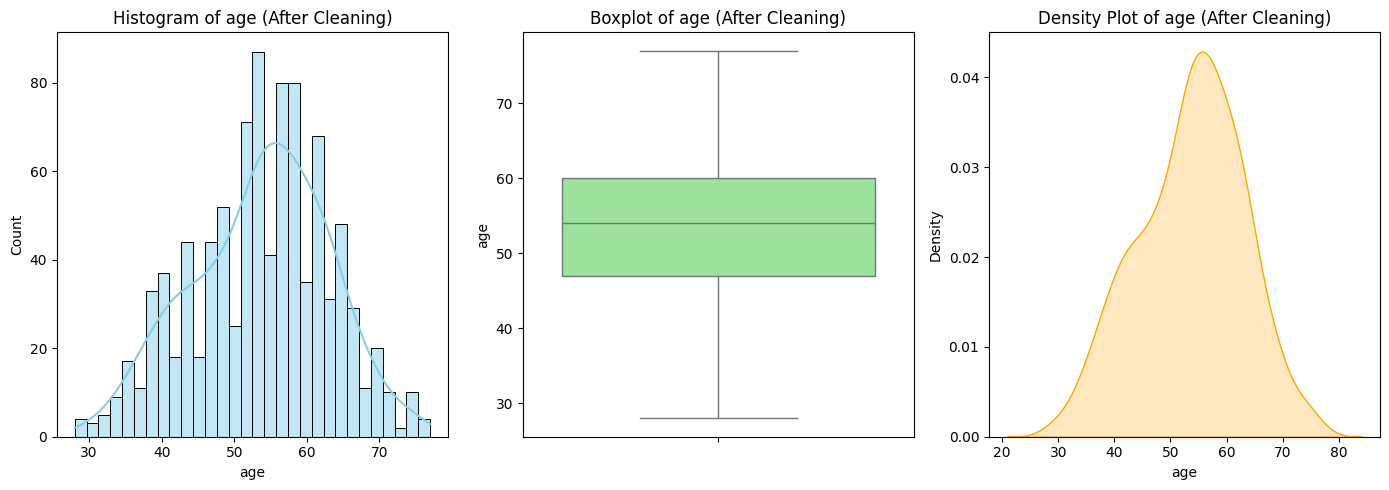

<ipython-input-24-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


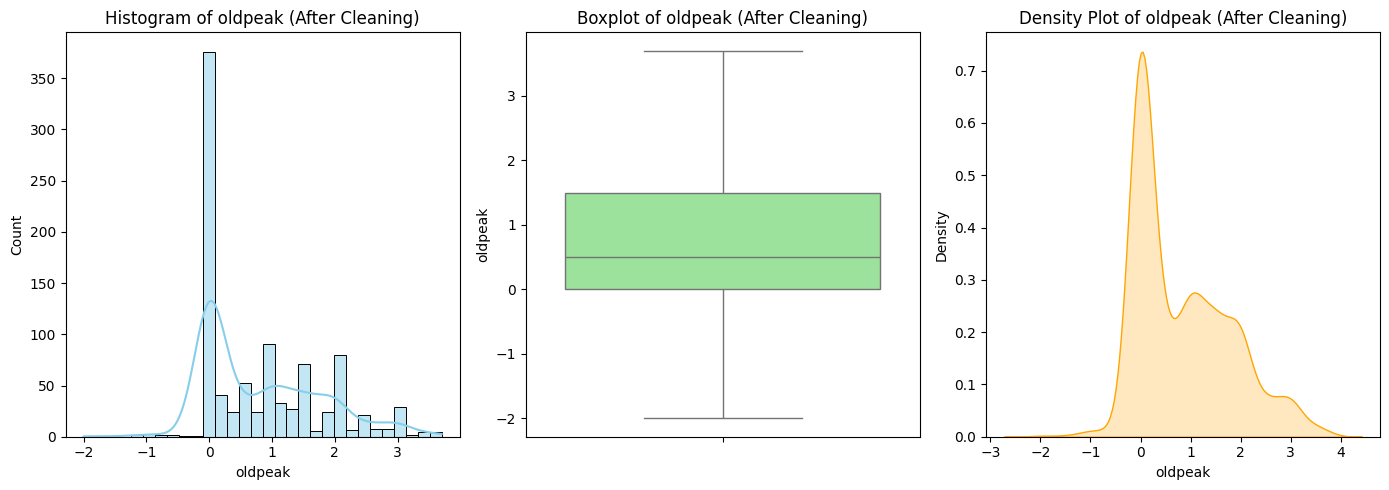

<ipython-input-24-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


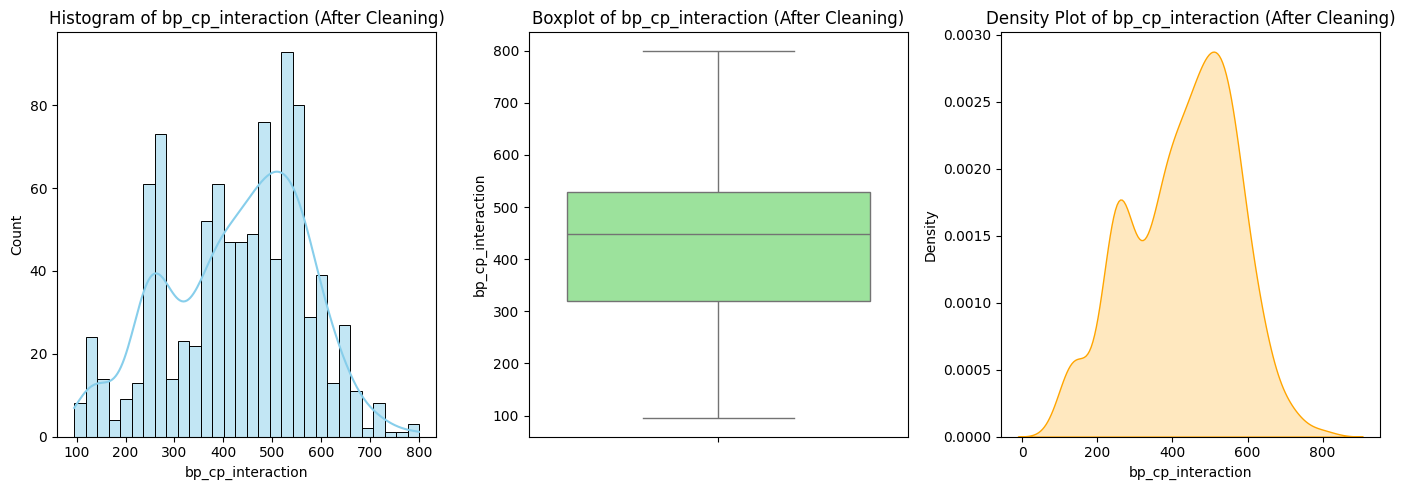

<ipython-input-24-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


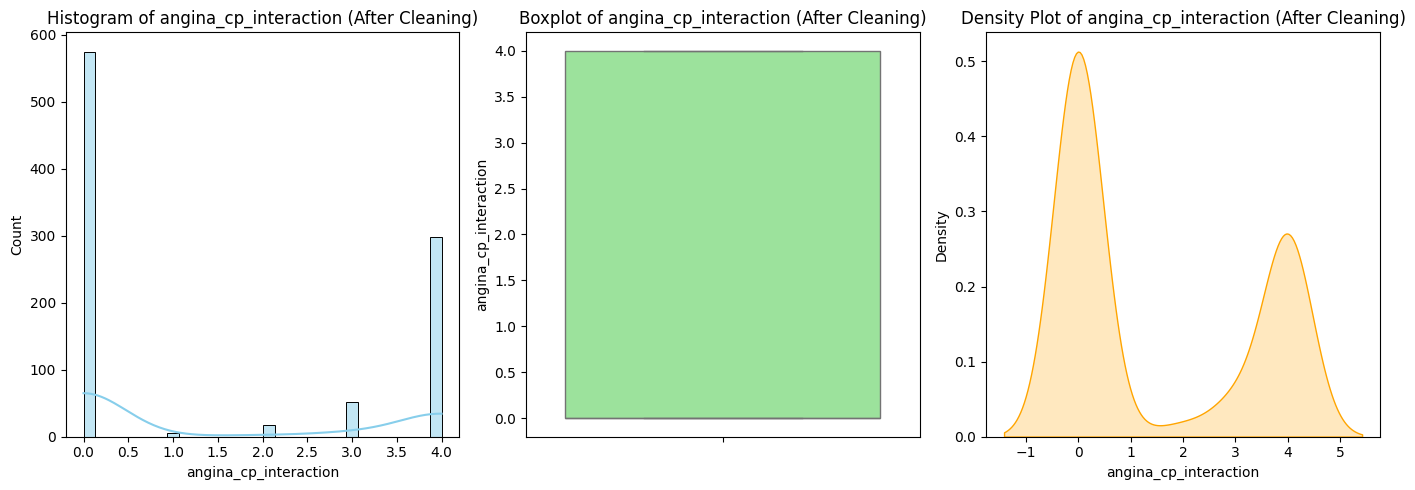

<ipython-input-24-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


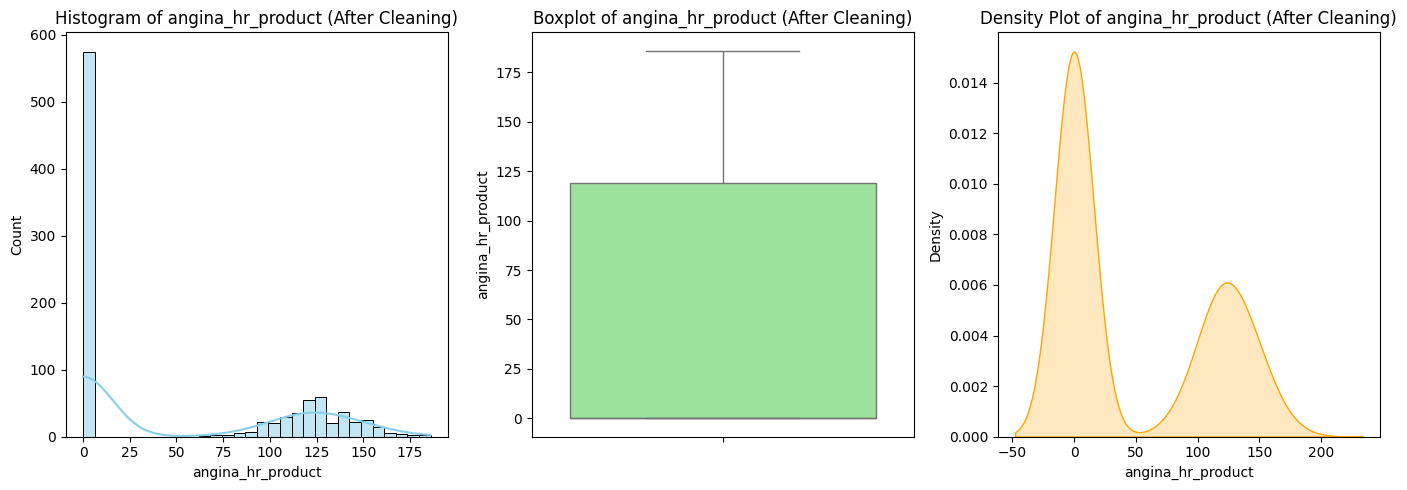

In [24]:
# after outlier replacement
for col in numeric_cols:
    plt.figure(figsize=(14, 5))

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col} (After Cleaning)')

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col} (After Cleaning)')

    # KDE plot
    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], shade=True, color='orange')
    plt.title(f'Density Plot of {col} (After Cleaning)')

    plt.tight_layout()
    plt.show()

In [25]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Toqa Hassan 202201868


In [26]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

print("\n Classification Report (Naive Bayes) ")
print(classification_report(y_test, y_pred))
print("\n Confusion Matrix ")
print(confusion_matrix(y_test, y_pred))


 Classification Report (Naive Bayes) 
              precision    recall  f1-score   support

           0       0.73      0.92      0.82        87
           1       0.91      0.72      0.80       103

    accuracy                           0.81       190
   macro avg       0.82      0.82      0.81       190
weighted avg       0.83      0.81      0.81       190


 Confusion Matrix 
[[80  7]
 [29 74]]


# **Naive Bayes**
Prediction: 98% probability of No Disease

Top Influencing Features:

slope <= -1.04: supports No Disease

fbs <= -0.55: supports No Disease

0.27 < cp <= 0.80: slightly supports Disease

Interpretation: The model heavily weighs slope and blood sugar toward a negative outcome. cp has a slightly effect.



In [27]:
# LIME Explainability
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

print("\n LIME Explanation for Naive Bayes ")
explanation = lime_explainer.explain_instance(
    data_row=X_test_scaled[0],
    predict_fn=nb_model.predict_proba,
    num_features=3
)
explanation.show_in_notebook(show_table=True)


 LIME Explanation for Naive Bayes 


# FLI

# Class 0 — No Disease
Lower values of features are typical.

Key indicators:

slope, angina_cp_interaction, and exang have the lowest means.

Most consistent features (lowest variance):

angina_cp_interaction, exang, and oldpeak.

# Class 1 — Disease
Higher values are more common.

Top signals:

slope, angina_cp_interaction, and exang have high positive means.

Most variable features:

fbs and angina_cp_interaction, showing greater spread among patients.



In [29]:
# Feature Likelihood Inspection
print("\n--- Feature Likelihood Inspection (Naive Bayes) ---")
features = X.columns.tolist()
class_labels = nb_model.classes_

for class_idx, class_val in enumerate(class_labels):
    print(f"\nClass {class_val} ({'Disease' if class_val == 1 else 'No Disease'}):")
    for i, feature in enumerate(features):
        mean = nb_model.theta_[class_idx, i]
        var = nb_model.var_[class_idx, i]
        print(f"  • {feature}: mean = {mean:.4f}, variance = {var:.4f}")



--- Feature Likelihood Inspection (Naive Bayes) ---

Class 0 (No Disease):
  • age: mean = -0.2949, variance = 1.0408
  • sex: mean = -0.2952, variance = 1.3448
  • cp: mean = -0.4877, variance = 0.9356
  • fbs: mean = -0.3066, variance = 0.5230
  • exang: mean = -0.5222, variance = 0.5088
  • oldpeak: mean = -0.4267, variance = 0.5235
  • slope: mean = -0.6144, variance = 0.7207
  • bp_cp_interaction: mean = -0.4883, variance = 0.8156
  • angina_cp_interaction: mean = -0.5407, variance = 0.4197
  • angina_hr_product: mean = -0.4865, variance = 0.5956

Class 1 (Disease):
  • age: mean = 0.2564, variance = 0.8232
  • sex: mean = 0.2565, variance = 0.5588
  • cp: mean = 0.4239, variance = 0.6695
  • fbs: mean = 0.2665, variance = 1.2618
  • exang: mean = 0.4539, variance = 0.9839
  • oldpeak: mean = 0.3709, variance = 1.1183
  • slope: mean = 0.5340, variance = 0.6294
  • bp_cp_interaction: mean = 0.4244, variance = 0.7730
  • angina_cp_interaction: mean = 0.4700, variance = 1.0294
  • 

# **PDP**
# Naive Bayes
bp_cp_interaction: Risk increases regularly

angina_cp_interaction: Linear increase — higher angina with chest pain raises risk.

angina_hr_product: Strong positive effect — high heart rate under angina increases predicted risk.




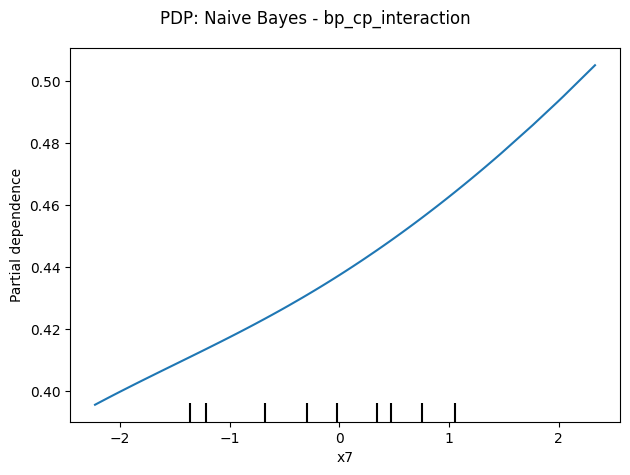

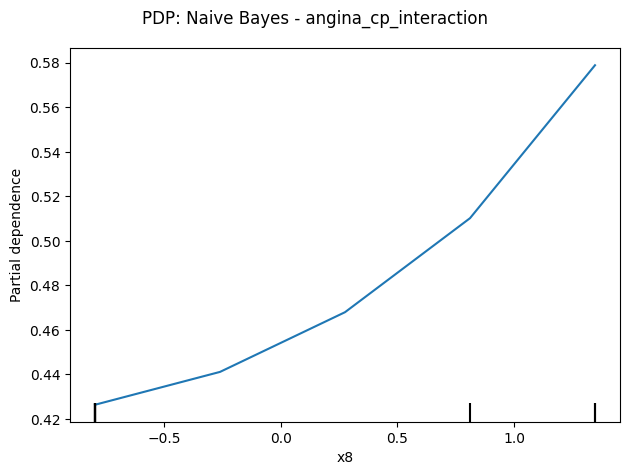

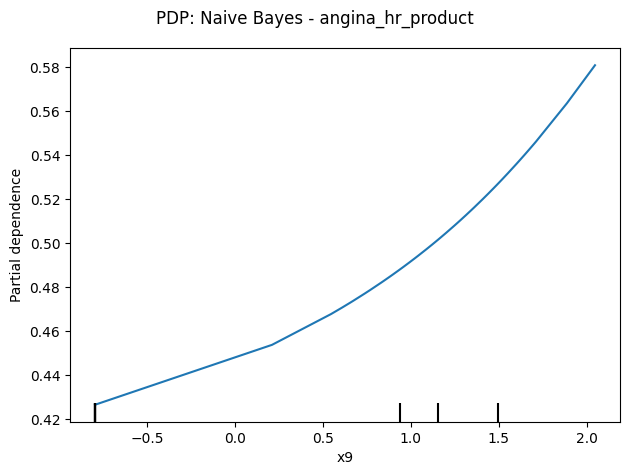

In [30]:
# PDP
important_features = ['bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product']
for f in important_features:
    PartialDependenceDisplay.from_estimator(nb_model, X_test_scaled, [X.columns.get_loc(f)], kind='average')
    plt.suptitle(f"PDP: Naive Bayes - {f}")
    plt.tight_layout()
    plt.show()


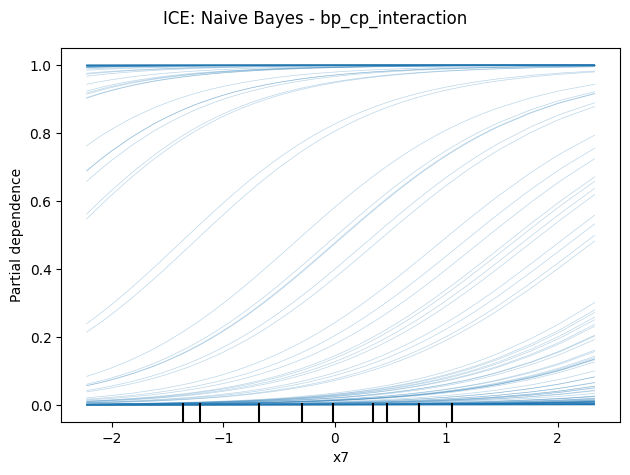

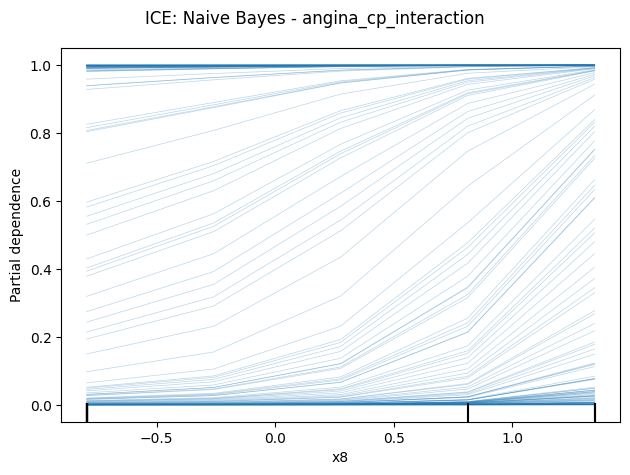

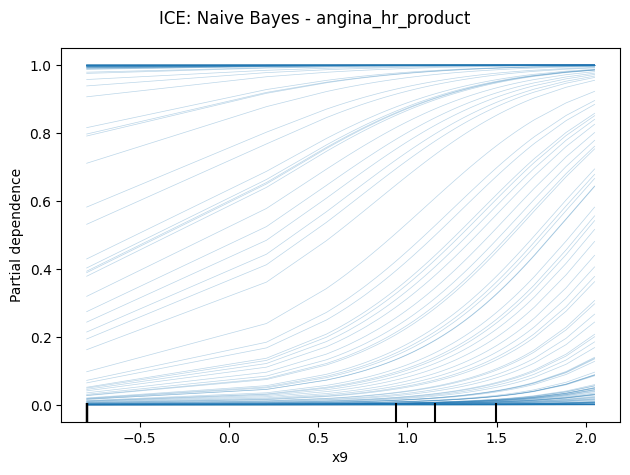

In [31]:
# ICE Plots
for f in important_features:
    PartialDependenceDisplay.from_estimator(nb_model, X_test_scaled, [X.columns.get_loc(f)], kind='individual')
    plt.suptitle(f"ICE: Naive Bayes - {f}")
    plt.tight_layout()
    plt.show()